In [ ]:
!pip install tensorflow matplotlib seaborn

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50  # ResNetRS50 does not exist in TensorFlow
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = "/content/Dataset"

In [ ]:
# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
# Data augmentation & preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)


Found 2006 images belonging to 5 classes.


In [ ]:
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 499 images belonging to 5 classes.


In [ ]:
# Load ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(train_generator.class_indices), activation='softmax')(x)

In [ ]:
# Compile the model
model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
epochs = 20
history = model.fit(train_generator, validation_data=val_generator, epochs=epochs)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 863ms/step - accuracy: 0.5798 - loss: 1.0007 - val_accuracy: 0.5772 - val_loss: 0.9877
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 856ms/step - accuracy: 0.5972 - loss: 0.9638 - val_accuracy: 0.5952 - val_loss: 0.9266
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 835ms/step - accuracy: 0.6219 - loss: 0.9392 - val_accuracy: 0.5691 - val_loss: 1.0142
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 990ms/step - accuracy: 0.6038 - loss: 0.9848 - val_accuracy: 0.6052 - val_loss: 0.9139
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 848ms/step - accuracy: 0.5955 - loss: 0.9602 - val_accuracy: 0.5271 - val_loss: 1.1765
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 841ms/step - accuracy: 0.6241 - loss: 0.9477 - val_accuracy: 0.5832 - val_loss: 0.9316
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 838ms/step - accuracy: 0.6100 - loss: 0.9417 - val_accuracy: 0.5772 - val_loss: 0.9683
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 840ms/step - accuracy: 0.6300 - loss: 0.9519 - val_accu

Text(0.5, 1.0, 'Accuracy')

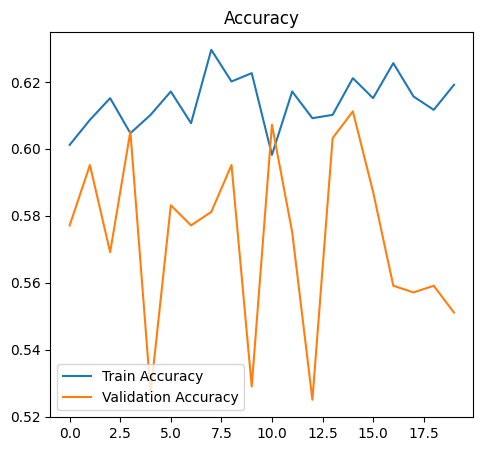

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

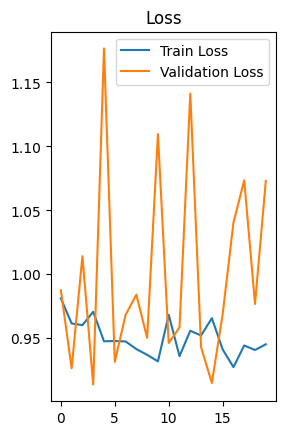

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

# My modification

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
path = "/content/drive/MyDrive/dataset/dataset"

In [ ]:
# Enhanced Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest',
    validation_split=0.2
)


In [ ]:
# Data Generators
train_generator = datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)


Found 2599 images belonging to 4 classes.


In [ ]:
val_generator = datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 647 images belonging to 4 classes.


In [ ]:
# Load ResNet50 with pre-trained ImageNet weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
# Unfreeze last 40 layers for fine-tuning
for layer in base_model.layers[-40:]:
    layer.trainable = True


In [ ]:
# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(len(train_generator.class_indices), activation='softmax')(x)

In [ ]:
# Compile Model with Optimized Learning Rate
model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Callbacks: Early Stopping & Learning Rate Scheduler
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

In [ ]:
# Train Model
epochs = 20
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop, lr_scheduler]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


Epoch 1/3:  20%|█▉        | 32/163 [16:19<1:06:51, 30.62s/batch]


82/82 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.7487 - loss: 0.6817 - val_accuracy: 0.1577 - val_loss: 3.4453 - learning_rate: 1.0000e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9867 - loss: 0.0498 - val_accuracy: 0.2952 - val_loss: 3.2425 - learning_rate: 1.0000e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9860 - loss: 0.0464 - val_accuracy: 0.3014 - val_loss: 1.4160 - learning_rate: 1.0000e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.2457 - val_loss: 2.8020 - learning_rate: 1.0000e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9863 - loss: 0.0418 - val_accuracy: 0.2457 - val_loss: 1.7021 - learning_rate: 1.0000e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.9840 - loss: 0.0703
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
82/82 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9840 - loss: 0.0701 - va

Text(0.5, 1.0, 'Accuracy')

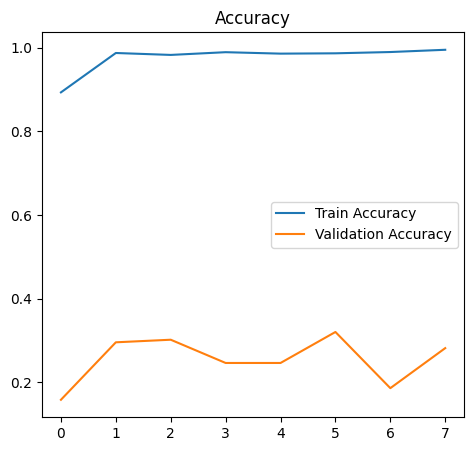

In [ ]:
# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

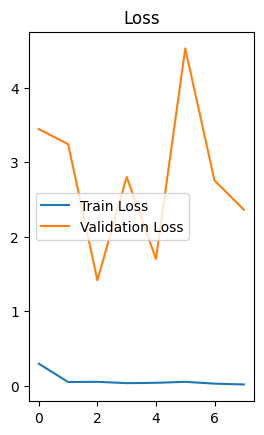

Final Training Accuracy: 0.9954
Final Validation Accuracy: 0.2813


In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

# Print Final Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")


In [ ]:
history

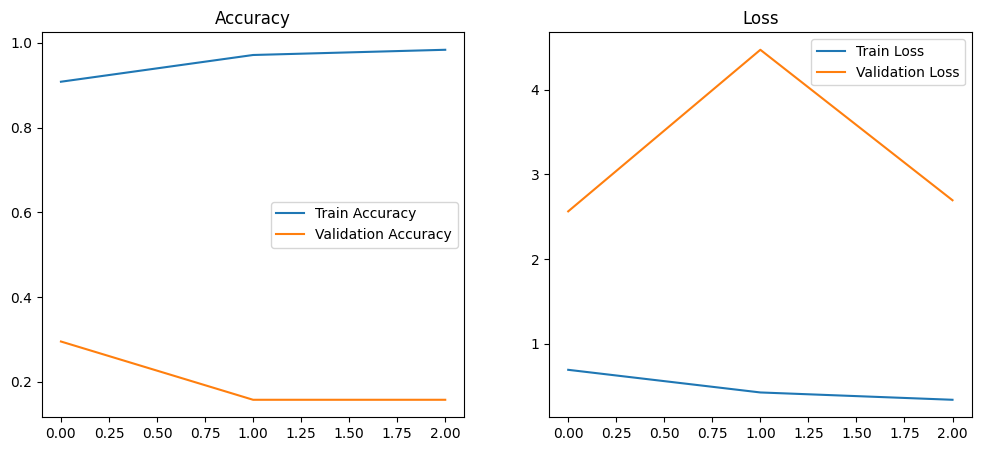

In [ ]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [ ]:
# Print Final Training & Validation Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")


Final Training Accuracy: 0.9838
Final Validation Accuracy: 0.1577


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
epochs = 3
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[TQDMProgressBar(), lr_scheduler, early_stop]  # Add early_stop to callbacks
)

Epoch 1/3:   0%|          | 0/163 [00:00<?, ?batch/s]

Epoch 1/3


Epoch 1/3:   1%|          | 1/163 [00:00<02:37,  1.03batch/s]

  1/163 ━━━━━━━━━━━━━━━━━━━━ 2:37 970ms/step - accuracy: 1.0000 - loss: 0.2586

Epoch 1/3:   1%|          | 2/163 [00:01<02:11,  1.22batch/s]

...

Epoch 1/3:  19%|█▉        | 31/163 [00:16<01:21,  1.63batch/s]

 31/163 ━━━━━━━━━━━━━━━━━━━━ 1:10 533ms/step - accuracy: 0.9816 - loss: 0.2918

Epoch 1/3:  20%|█▉        | 32/163 [00:17<01:15,  1.74batch/s]

 32/163 ━━━━━━━━━━━━━━━━━━━━ 1:09 532ms/step - accuracy: 0.9816 - loss: 0.2919

KeyboardInterrupt: 

# Mobilenet

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ✅ Dataset Path
data_dir = "/content/drive/MyDrive/dataset/dataset"

# ✅ Image Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation'
)

Found 2599 images belonging to 4 classes.
Found 647 images belonging to 4 classes.


In [ ]:
# ✅ Load MobileNetV2 (Lightweight & Efficient)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze initial layers

# ✅ Custom Classifier Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(len(train_generator.class_indices), activation='softmax')(x)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# ✅ Compile Model
model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# ✅ Early Stopping (Stops if no improvement)
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)


In [ ]:
# ✅ Train Model
epochs = 20
history = model.fit(train_generator, validation_data=val_generator, epochs=epochs, callbacks=[early_stop])


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4651 - loss: 1.2988 - val_accuracy: 0.7883 - val_loss: 0.6020
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8297 - loss: 0.5014 - val_accuracy: 0.8408 - val_loss: 0.4315
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8859 - loss: 0.3348 - val_accuracy: 0.8686 - val_loss: 0.3685
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9208 - loss: 0.2436 - val_accuracy: 0.9181 - val_loss: 0.2770
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9441 - loss: 0.2028 - val_accuracy: 0.9042 - val_loss: 0.2710
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9502 - loss: 0.1775 - val_accuracy: 0.9258 - val_loss: 0.2280
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9544 - loss: 0.1534 - val_accuracy: 0.9227 - val_loss: 0.2277
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9655 - loss: 0.1317 - val_accuracy: 0.9413 - val_los

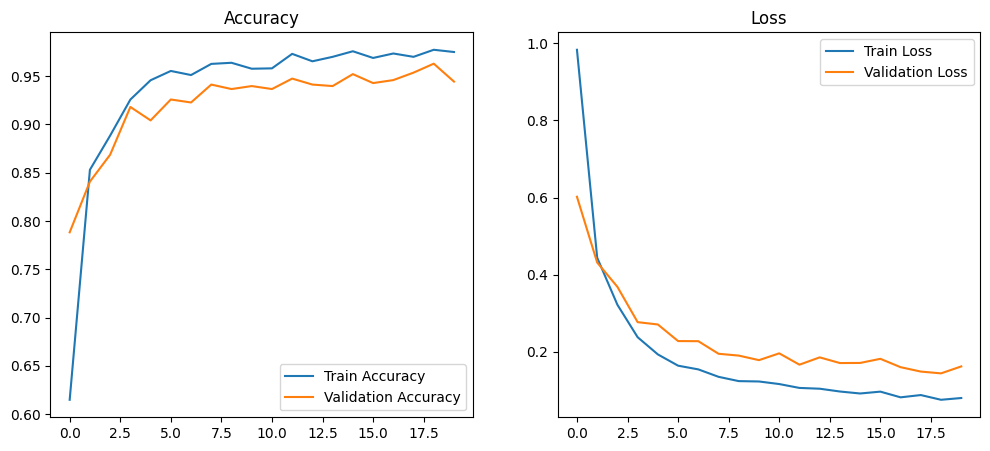

In [ ]:
# ✅ Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [ ]:
model.save('/content/mobilenetv2_model.h5')  # Saves the entire model

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


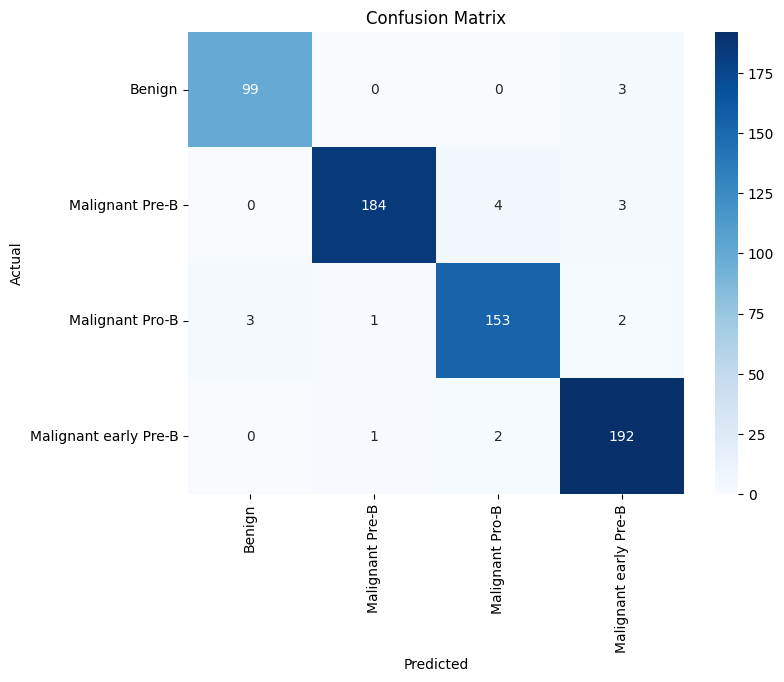

Classification Report:
                        precision    recall  f1-score   support

               Benign       0.97      0.97      0.97       102
      Malignant Pre-B       0.99      0.96      0.98       191
      Malignant Pro-B       0.96      0.96      0.96       159
Malignant early Pre-B       0.96      0.98      0.97       195

             accuracy                           0.97       647
            macro avg       0.97      0.97      0.97       647
         weighted avg       0.97      0.97      0.97       647



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# ✅ Get Predictions
y_true = []
y_pred = []

for images, labels in val_generator:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))  # Predicted labels
    if len(y_true) >= val_generator.samples:  # Stop when all samples are covered
        break

# ✅ Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(val_generator.class_indices.keys())

# ✅ Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))


In [ ]:
# ✅ 2️⃣ Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:
                        precision    recall  f1-score   support

               Benign       0.97      0.97      0.97       102
      Malignant Pre-B       0.99      0.96      0.98       191
      Malignant Pro-B       0.96      0.96      0.96       159
Malignant early Pre-B       0.96      0.98      0.97       195

             accuracy                           0.97       647
            macro avg       0.97      0.97      0.97       647
         weighted avg       0.97      0.97      0.97       647



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


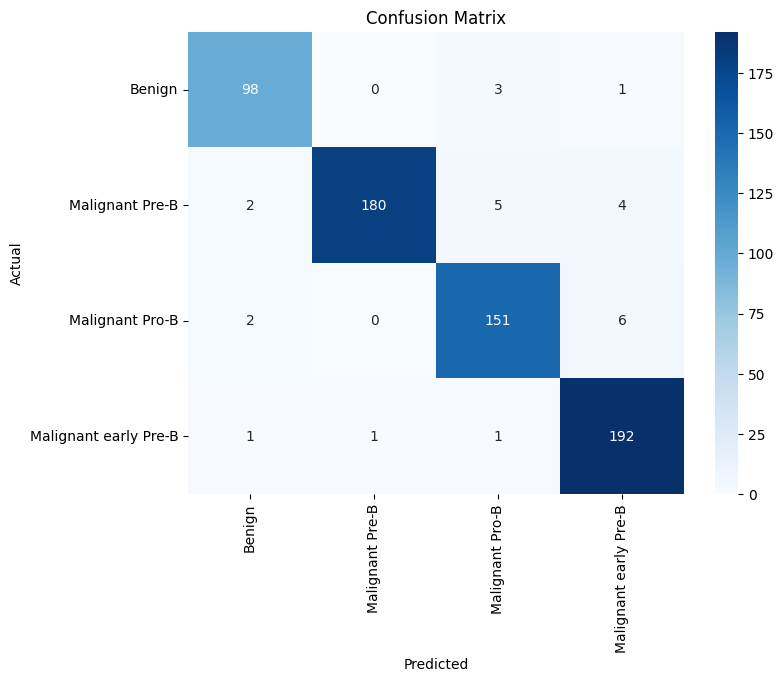

Classification Report:
                        precision    recall  f1-score   support

               Benign       0.95      0.96      0.96       102
      Malignant Pre-B       0.99      0.94      0.97       191
      Malignant Pro-B       0.94      0.95      0.95       159
Malignant early Pre-B       0.95      0.98      0.96       195

             accuracy                           0.96       647
            macro avg       0.96      0.96      0.96       647
         weighted avg       0.96      0.96      0.96       647



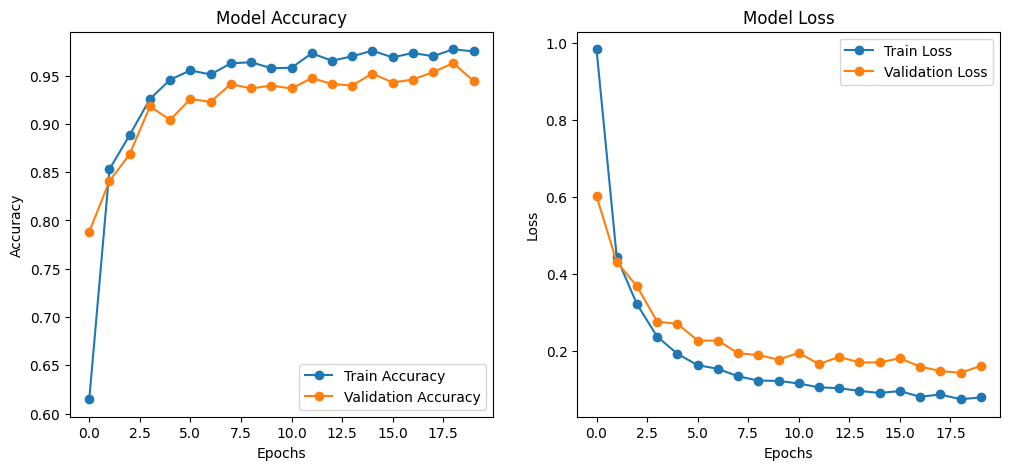

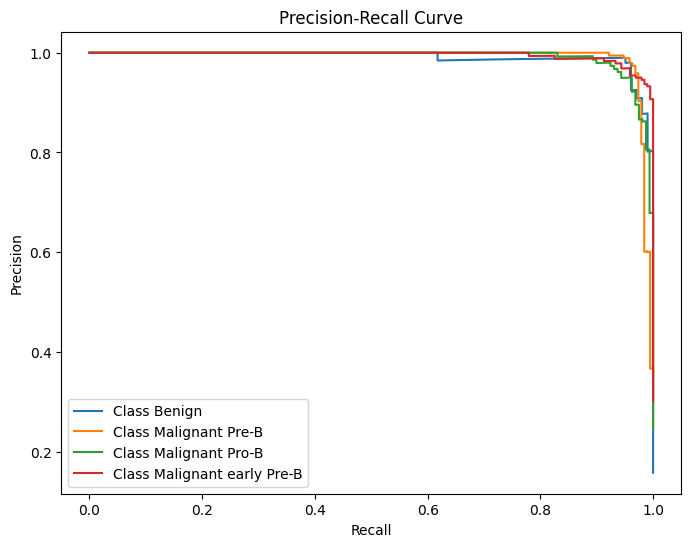

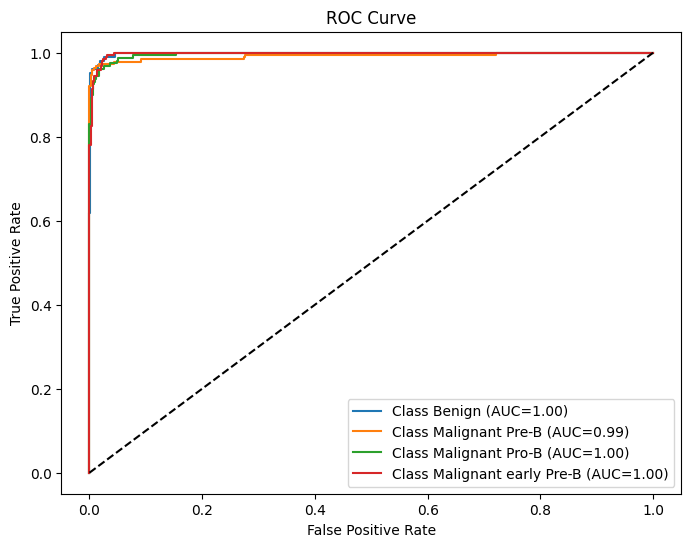

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from tensorflow.keras.utils import to_categorical

# ✅ Get Predictions
y_true = []
y_pred = []
y_prob = []

for images, labels in val_generator:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))  # Predicted labels
    y_prob.extend(preds)  # Raw probability scores
    if len(y_true) >= val_generator.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)
class_labels = list(val_generator.class_indices.keys())

# ✅ 1️⃣ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ 2️⃣ Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# ✅ 3️⃣ Accuracy & Loss Graphs
plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

# ✅ 4️⃣ Precision-Recall Curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    precision, recall, _ = precision_recall_curve(to_categorical(y_true, len(class_labels))[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f'Class {class_labels[i]}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ✅ 5️⃣ ROC Curve (for multi-class classification)
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(to_categorical(y_true, len(class_labels))[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC={auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
